In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns



def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):

    # === 경로 수정 ===
    # 알려주신 Colab 경로로 기본 경로를 수정합니다.
    base_path = '/content/drive/MyDrive/Colab Notebooks/ML/UCI-HAR/'

    # load all train
    trainX, trainy = load_dataset_group('train', prefix + base_path)
    # load all test
    testX, testy = load_dataset_group('test', prefix + base_path)
    # === 경로 수정 완료 ===

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print("trainX shape:", trainX.shape)
    print("trainy shape:", trainy.shape)
    print("trainy_one_hot shape:", trainy_one_hot.shape)
    print("testX shape:", testX.shape)
    print("testy shape:", testy.shape)
    print("testy_one_hot shape:", testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

# --- 이 함수를 다시 호출하여 데이터를 로드합니다 ---
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

# --- 데이터 분할 (기존 코드와 동일) ---
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)

print("\n--- 분할 후 데이터 Shape ---")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train_one_hot shape:", y_train_one_hot.shape)
print("y_val_one_hot shape:", y_val_one_hot.shape)

/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=Tr

trainX shape: (7352, 128, 9)
trainy shape: (7352, 1)
trainy_one_hot shape: (7352, 6)
testX shape: (2947, 128, 9)
testy shape: (2947, 1)
testy_one_hot shape: (2947, 6)

--- 분할 후 데이터 Shape ---
X_train shape: (5881, 128, 9)
X_val shape: (1471, 128, 9)
y_train_one_hot shape: (5881, 6)
y_val_one_hot shape: (1471, 6)


In [2]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]

In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers

# 1. 모델 구성 (GRU)
# -----------------------------
# n_timesteps=128, n_features=9, n_outputs=6

model_3 = models.Sequential([
    # GRU 레이어 1: 64 유닛
    # input_shape는 (타임스텝, 특징 수)입니다.
    # return_sequences=True는 다음 GRU 레이어에
    # 전체 시퀀스를 전달하기 위해 필요합니다.
    layers.GRU(64, return_sequences=True,
               input_shape=(n_timesteps, n_features)),

    # GRU 레이어 2: 32 유닛
    # 마지막 순환 레이어이므로 return_sequences=False (기본값)
    layers.GRU(32),

    # 은닉층 (Classifier)
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.5), # 과적합 방지를 위한 Dropout

    # 출력층: 6개의 클래스를 분류
    layers.Dense(n_outputs, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# 2. 모델 컴파일
# -----------------------------
model_3.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 모델 구조 요약
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,714 (108.26 KB)

 Trainable params: 27,714 (108.26 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 3. 모델 학습
# -----------------------------
# epochs, batch_size는 CNN 모델과 동일하게 30, 64로 설정합니다.
epochs = 30
batch_size = 64

history_3 = model_3.fit(X_train, y_train_one_hot,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(X_val, y_val_one_hot),
                      verbose=1)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 248ms/step - accuracy: 0.3793 - loss: 1.5308 - val_accuracy: 0.5901 - val_loss: 1.0063
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.5944 - loss: 0.9438 - val_accuracy: 0.7213 - val_loss: 0.6687
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 184ms/step - accuracy: 0.7230 - loss: 0.6622 - val_accuracy: 0.8205 - val_loss: 0.4788
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.8395 - loss: 0.4277 - val_accuracy: 0.8661 - val_loss: 0.3671
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 183ms/step - accuracy: 0.8891 - loss: 0.3386 - val_accuracy: 0.9048 - val_loss: 0.2501
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.9200 - loss: 0.2412 - val_accuracy: 0.9307 - val_loss: 0.2195
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 185ms/step - accuracy: 0.9300 - loss: 0.2079 - val_accuracy: 0.8994 - val_loss: 0.2380
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step - accuracy: 0.9341 - loss: 0.1832 - val_accu

In [6]:
# 4. 모델 평가 (Test set)
# -----------------------------
print("\n--- 3. GRU 모델 테스트 평가 ---")
test_loss_3, test_acc_3 = model_3.evaluate(testX, testy_one_hot, verbose=2)
print(f"\nTest Accuracy (GRU): {test_acc_3*100:.2f}%")


--- 3. GRU 모델 테스트 평가 ---
93/93 - 2s - 26ms/step - accuracy: 0.9040 - loss: 0.4416

Test Accuracy (GRU): 90.40%


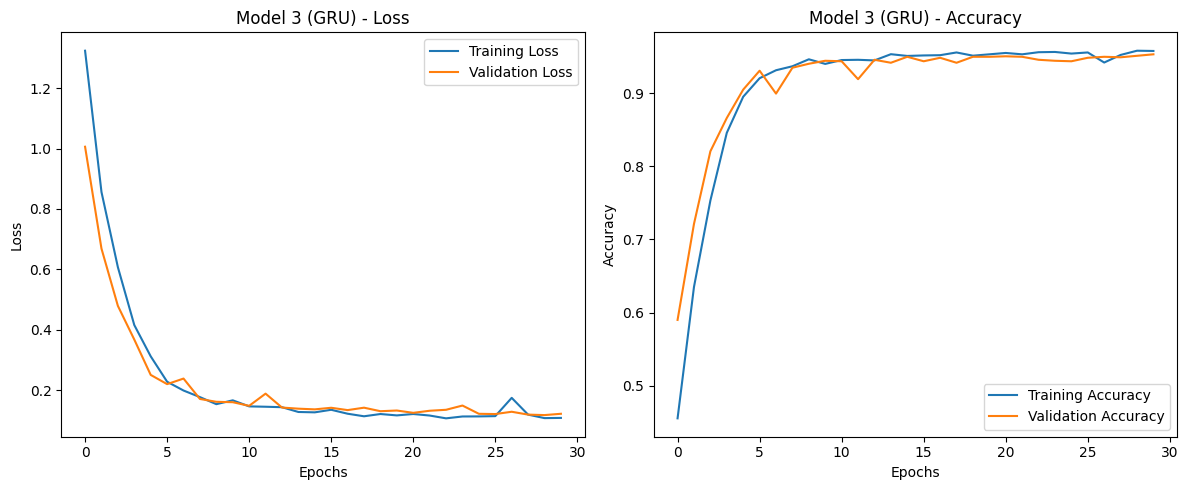

In [7]:
# 5. 학습 과정 시각화
# -----------------------------
plt.figure(figsize=(12, 5))

# 손실(Loss) 그래프
plt.subplot(1, 2, 1)
plt.plot(history_3.history['loss'], label='Training Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.title('Model 3 (GRU) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 2)
plt.plot(history_3.history['accuracy'], label='Training Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 3 (GRU) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()